In [1]:
import pickle
import sys
from pathlib import Path

import numpy as np
from sklearn.cluster import KMeans
from vedo import Volume, Plotter

# Ensure we can import from the src directory
sys.path.insert(0, str(Path("../../src").resolve()))
from helper_functions import otsu_threshold


In [5]:
# --- Configuration ---
specimen = "GH"
image_name = "gras_9_043"  # Change to your specific test image

project_root = Path("../../").resolve()
print(project_root)
raw_tiff_path = project_root / "data" / "raw" / "bugNIST_900" / specimen / f"{image_name}.tif"
inferred_pkl_path = project_root / "data" / "infered" / "bugNIST_900" / specimen / f"{image_name}.pkl"

# 1. Load the raw volume
print(f"Loading raw TIFF from {raw_tiff_path}...")
raw_vol = Volume(str(raw_tiff_path))
raw_data = raw_vol.tonumpy().astype(np.float32)
spacing = raw_vol.spacing()
origin = raw_vol.origin()
volume_shape = raw_data.shape

# 2. Load the inferred embeddings
print(f"Loading embeddings from {inferred_pkl_path.name}...")
with open(inferred_pkl_path, "rb") as f:
    voxel_embeddings = pickle.load(f)
    
print(f"Loaded embeddings for {len(voxel_embeddings):,} voxels.")

/home/lyngsberg/bachelor_project
Loading raw TIFF from /home/lyngsberg/bachelor_project/data/raw/bugNIST_900/GH/gras_9_043.tif...
Loading embeddings from gras_9_043.pkl...
Loaded embeddings for 405,664 voxels.


In [6]:
# 1. Extract the coordinates and the FIRST embedding
coords = []
embs = []

for (ix, iy, iz), emb_list in voxel_embeddings.items():
    coords.append((ix, iy, iz))
    embs.append(emb_list[0])  # Pick the first embedding

coords = np.array(coords)
embs = np.array(embs)  # Shape: (N, hidden_dim)

# 2. Cluster the embeddings into 5 components
print("Running K-Means clustering to find 5 components...")
kmeans = KMeans(n_clusters=5, random_state=42)
labels = kmeans.fit_predict(embs)  # Results in labels 0 through 4

# 3. Create an empty volume for our clusters
# We use 0 as the background, so we shift the cluster labels to 1-5
cluster_vol_data = np.zeros(volume_shape, dtype=np.uint8)

for (ix, iy, iz), label in zip(coords, labels):
    cluster_vol_data[ix, iy, iz] = label + 1

# 4. Apply Otsu threshold to mask out background noise completely
print("Applying Otsu threshold to clean up background...")
mask = otsu_threshold(raw_data, log_scale=True)
cluster_vol_data[~mask] = 0

print("Volume processing complete.")

Running K-Means clustering to find 5 components...
Applying Otsu threshold to clean up background...
Volume processing complete.


Preparing vedo render...
Opening viewer... Rotate the model to see the clustered embeddings!


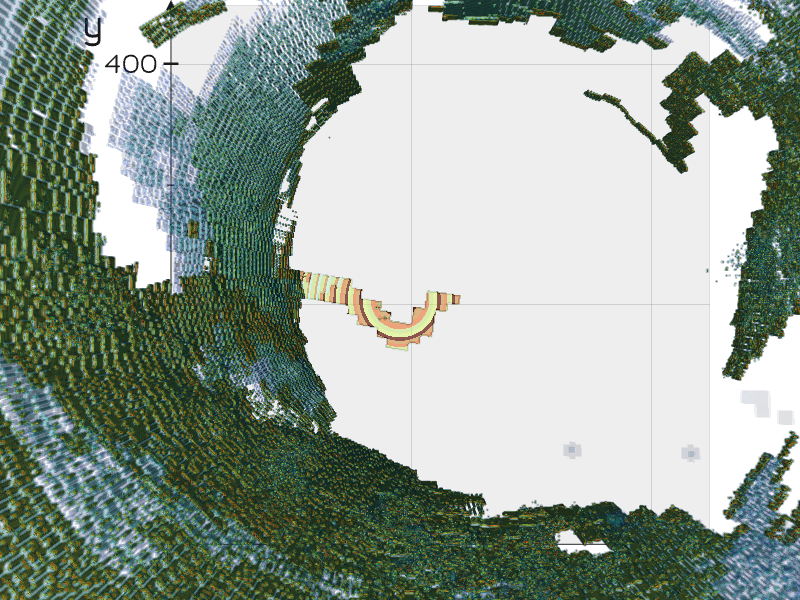

In [7]:
print("Preparing vedo render...")

# 1. Create the clean volume, preserving the original geometry
clean_vol = Volume(cluster_vol_data, spacing=spacing, origin=origin)

# 2. Apply visualization settings
# Background (0) gets alpha 0. The clusters (1-5) get higher opacities.
clean_vol.mode(0).cmap("jet").alpha([0, 0.2, 0.8, 1])

# 3. Create Plotter without the HUD
plt = Plotter(axes=1, title="Embedding Clusters Viewer")

print("Opening viewer... Rotate the model to see the clustered embeddings!")
plt.show(clean_vol, interactive=True)